# Non-Invasive Blood Glucose Estimation: Pilot ML Model with Real Data

This notebook trains, evaluates, and performs robust correlation analysis on a machine learning model using the real PPG dataset collected so far (`glucosense_r_dataset_2026-08-27.csv`).

## Key Pipeline Features:
1. **Signal Preprocessing**: Clean raw PPG signals using a stable 60-second window (ignoring 10-second stabilization).
2. **Rich Feature Extraction**: Extract HRV/PRV time-domain, non-linear, and morphological features using `neurokit2`.
3. **Robust Correlation Analysis**: Generate a Pearson correlation table of all extracted PPG features against measured Blood Glucose Levels (BGL) to identify key predictors.
4. **Machine Learning Model**: Train and evaluate regressors (Random Forest and Gradient Boosting) with 5-Fold Cross-Validation.

In [1]:
print("starting")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
from scipy.stats import skew, kurtosis
from scipy.interpolate import interp1d
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, GroupKFold, LeaveOneOut, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import xgboost as xgb

try:
    import catboost as cb
    has_catboost = True
except ImportError:
    has_catboost = False

try:
    import lightgbm as lgb
    has_lightgbm = True
except ImportError:
    has_lightgbm = False

# Set style for modern aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150

csv_path = "data/real/glucosense_r_dataset_2026-09-04.csv"
sampling_rate = 50  # 50 Hz acquisition rate
print(f"✓ Imports completed. CatBoost: {has_catboost}, LightGBM: {has_lightgbm}, XGBoost: True.")

starting
✓ Imports completed. CatBoost: True, LightGBM: True, XGBoost: True.


In [3]:
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Dataset file not found at {csv_path}")

df = pd.read_csv(csv_path)
print(f"✓ Dataset loaded. Total records: {len(df)}")
print("\nFirst 3 rows:")
display(df.head(3))

print("\nSession kinds distribution:")
print(df['session_kind'].value_counts())

✓ Dataset loaded. Total records: 73

First 3 rows:


,session_id,created_at,participant_id,age,gender,weight_kg,height_cm,years_on_t2dm,medication,session_kind,bgl_mgdl,ppg_samples_count,ppg_data
0,fce4b7a2-b3db-4b11-81e7-9c8f8ace228d,2026-08-06T09:03:50.335985+00:00,P001,73,Female,74.0,120.0,8,"Alphabetuc+, glepid-2, sealmet, trevisa",fasting,196,3500,57994;58030;58020;58027;58013;58039;58044;5805...
1,07dc95d8-8001-417f-b139-d4faf092b371,2026-08-06T10:34:31.431381+00:00,P001,73,Female,74.0,120.0,8,"Alphabetuc+, glepid-2, sealmet, trevisa",1hr_post_prandial,269,3500,59419;59453;59470;59475;59513;59507;59529;5956...
2,2fb9eb9e-4f36-4749-bb66-78510db5dde9,2026-08-27T07:56:02.871753+00:00,P002,63,Female,79.0,172.0,21,NaN,fasting,190,3500,55490;55479;55469;55480;55473;55469;55476;5548...



Session kinds distribution:
session_kind
fasting              40
2hr_post_prandial    22
1hr_post_prandial    11
Name: count, dtype: int64


In [4]:
def extract_paper_pulse_features(avg_beat):
    """
    Extract complete statistical, time-domain, and spectral features from averaged beat as used in PPG literature:
    - Peak value, Peak-to-peak, Mean value, Standard deviation, RMS
    - Skewness, Kurtosis, Crest factor, Impulse factor, Median diff, Upstroke Slope, Spectral Entropy
    """
    from scipy.stats import entropy
    
    peak_val = float(np.max(avg_beat))
    trough_val = float(np.min(avg_beat))
    peak_to_peak = peak_val - trough_val
    mean_val = float(np.mean(avg_beat))
    std_val = float(np.std(avg_beat))
    rms_val = float(np.sqrt(np.mean(avg_beat**2)))
    skew_val = float(skew(avg_beat))
    kurt_val = float(kurtosis(avg_beat))
    
    crest_factor = float(peak_val / (rms_val + 1e-5))
    impulse_factor = float(peak_val / (mean_val + 1e-5))
    median_diff = float(np.median(np.abs(np.diff(avg_beat))))
    slope = float(np.max(np.gradient(avg_beat)))
    
    # Power Spectral Density & Spectral Entropy (0_spectral_entropy)
    fft_vals = np.abs(np.fft.rfft(avg_beat))**2
    psd_norm = fft_vals / (np.sum(fft_vals) + 1e-8)
    spec_entropy = float(entropy(psd_norm + 1e-12, base=2))
    
    raw_dict = {
        'peak_val': peak_val,
        'peak_to_peak': peak_to_peak,
        'mean_val': mean_val,
        'std_val': std_val,
        'rms_val': rms_val,
        'skewness': skew_val,
        'kurtosis': kurt_val,
        'crest_factor': crest_factor,
        'impulse_factor': impulse_factor,
        'median_diff': median_diff,
        'slope': slope,
        'spectral_entropy': spec_entropy
    }
    return {k: (0.0 if np.isinf(v) or np.isnan(v) else v) for k, v in raw_dict.items()}

def extract_apg_landmarks(avg_beat):
    vpg = np.gradient(avg_beat)
    apg = np.gradient(vpg)
    len_b = len(avg_beat)
    
    a_idx = np.argmax(apg[:int(len_b * 0.35)])
    a_val = apg[a_idx] if apg[a_idx] > 0 else 1e-5
    
    search_b_end = int(len_b * 0.5)
    if search_b_end > a_idx + 2:
        b_idx = a_idx + np.argmin(apg[a_idx:search_b_end])
        b_val = apg[b_idx]
    else:
        b_val = 0.0
        
    search_c_end = int(len_b * 0.65)
    if 'b_idx' in locals() and search_c_end > b_idx + 1:
        c_idx = b_idx + np.argmax(apg[b_idx:search_c_end])
        c_val = apg[c_idx]
    else:
        c_val = 0.0
        
    search_d_end = int(len_b * 0.8)
    if 'c_idx' in locals() and search_d_end > c_idx + 1:
        d_idx = c_idx + np.argmin(apg[c_idx:search_d_end])
        d_val = apg[d_idx]
    else:
        d_val = 0.0
        
    if 'd_idx' in locals() and len_b > d_idx + 1:
        e_idx = d_idx + np.argmax(apg[d_idx:])
        e_val = apg[e_idx]
    else:
        e_val = 0.0

    b_a = b_val / a_val
    c_a = c_val / a_val
    d_a = d_val / a_val
    e_a = e_val / a_val
    
    aging_index = (b_val - c_val - d_val - e_val) / a_val
    elasticity_index = (b_val - c_val - d_val) / a_val
    deceleration_index = (d_val - e_val) / a_val
    
    raw_dict = {
        'apg_a': a_val, 'apg_b': b_val, 'apg_c': c_val, 'apg_d': d_val, 'apg_e': e_val,
        'b_a_ratio': b_a, 'c_a_ratio': c_a, 'd_a_ratio': d_a, 'e_a_ratio': e_a,
        'aging_index': aging_index, 'elasticity_index': elasticity_index, 'deceleration_index': deceleration_index
    }
    return {k: (0.0 if np.isinf(v) or np.isnan(v) else v) for k, v in raw_dict.items()}

def process_session_with_averaging(ppg_raw, sampling_rate=50):
    cleaned = nk.ppg_clean(ppg_raw, sampling_rate=sampling_rate, method='elgendi')
    signals, info = nk.ppg_process(cleaned, sampling_rate=sampling_rate, method='elgendi')
    peaks = info['PPG_Peaks']
    hrv_df = nk.ppg_analyze(signals, sampling_rate=sampling_rate)
    
    troughs = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        if p2 - p1 > 10:
            troughs.append(p1 + np.argmin(cleaned[p1:p2]))
            
    valid_beats = []
    target_len = 100
    for i in range(len(troughs) - 1):
        t1, t2 = troughs[i], troughs[i+1]
        beat_len = t2 - t1
        if 18 <= beat_len <= 80:
            beat = cleaned[t1:t2]
            x_old = np.linspace(0, 1, len(beat))
            x_new = np.linspace(0, 1, target_len)
            beat_resampled = interp1d(x_old, beat, kind='cubic')(x_new)
            b_min, b_max = beat_resampled.min(), beat_resampled.max()
            if b_max - b_min > 1e-5:
                valid_beats.append((beat_resampled - b_min) / (b_max - b_min))
                
    if len(valid_beats) < 3:
        avg_beat = np.zeros(target_len)
        num_valid_beats = 0
    else:
        valid_beats_arr = np.array(valid_beats)
        median_beat = np.median(valid_beats_arr, axis=0)
        corrs = [np.corrcoef(b, median_beat)[0, 1] for b in valid_beats_arr]
        clean_beats = [b for b, c in zip(valid_beats_arr, corrs) if c > 0.8]
        avg_beat = np.mean(clean_beats, axis=0) if len(clean_beats) >= 2 else median_beat
        num_valid_beats = len(clean_beats) if len(clean_beats) >= 2 else len(valid_beats)
        
    s_peak_idx = np.argmax(avg_beat)
    s_peak_val = avg_beat[s_peak_idx]
    if s_peak_idx + 5 < target_len - 10:
        d_peak_idx = s_peak_idx + 5 + np.argmax(avg_beat[s_peak_idx+5:target_len-5])
        d_peak_val = avg_beat[d_peak_idx]
    else:
        d_peak_val = 0.0
        
    vpg_avg = np.gradient(avg_beat)
    apg_avg = np.gradient(vpg_avg)
    
    avg_feats = {
        'num_valid_beats': num_valid_beats,
        'avg_ppg_amp': s_peak_val,
        'avg_ppg_skew': skew(avg_beat),
        'avg_ppg_kurt': kurtosis(avg_beat),
        'avg_vpg_amp': np.max(vpg_avg) - np.min(vpg_avg),
        'avg_vpg_max_upstroke': np.max(vpg_avg),
        'avg_vpg_skew': skew(vpg_avg),
        'avg_apg_amp': np.max(apg_avg) - np.min(apg_avg),
        'avg_apg_skew': skew(apg_avg),
        'reflection_index': d_peak_val / (s_peak_val + 1e-5),
    }
    
    avg_feats.update(extract_paper_pulse_features(avg_beat))
    avg_feats.update(extract_apg_landmarks(avg_beat))
    
    for col in hrv_df.columns:
        val = hrv_df[col].values[0]
        if not pd.isna(val):
            avg_feats[col] = val
            
    return avg_feats

features_list = []
skipped_rows = 0
print("Extracting pulse-segmented, averaged & paper-specific statistical/spectral features...")

for idx, row in df.iterrows():
    if pd.isna(row['bgl_mgdl']) or pd.isna(row['ppg_data']):
        skipped_rows += 1
        continue
    try:
        ppg_signal = np.array([float(x) for x in str(row['ppg_data']).split(';') if x.strip()])
        if len(ppg_signal) < 3500:
            skipped_rows += 1
            continue
        active_signal = ppg_signal[500:3500]
        
        feat_dict = process_session_with_averaging(active_signal, sampling_rate=sampling_rate)
        feat_dict['participant_id'] = row['participant_id']
        feat_dict['session_kind'] = row['session_kind']
        feat_dict['age'] = row['age']
        feat_dict['gender'] = 1 if row['gender'] == 'Male' else 0
        feat_dict['weight_kg'] = row['weight_kg']
        feat_dict['height_cm'] = row['height_cm']
        feat_dict['years_on_t2dm'] = row['years_on_t2dm']
        feat_dict['bgl_mgdl'] = float(row['bgl_mgdl'])
        
        features_list.append(feat_dict)
    except Exception as e:
        skipped_rows += 1
        continue

feat_df = pd.DataFrame(features_list)
print(f"✓ Extract completed. Valid sessions: {len(feat_df)}, Skipped: {skipped_rows}")
print(f"Total features per session: {feat_df.shape[1]}")

Extracting pulse-segmented, averaged & paper-specific statistical/spectral features...


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for th

✓ Extract completed. Valid sessions: 73, Skipped: 0
Total features per session: 121


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


--- Feature Correlation Table (Sorted by absolute strength) ---


,Pearson_r,Absolute_r
peak_to_peak,0.314436,0.314436
avg_ppg_amp,0.305377,0.305377
peak_val,0.305377,0.305377
e_a_ratio,0.303885,0.303885
apg_e,0.302315,0.302315
...,...,...
HRV_VHF,-0.011640,0.011640
apg_b,0.007252,0.007252
HRV_MSEn,0.007010,0.007010
avg_vpg_skew,-0.004410,0.004410


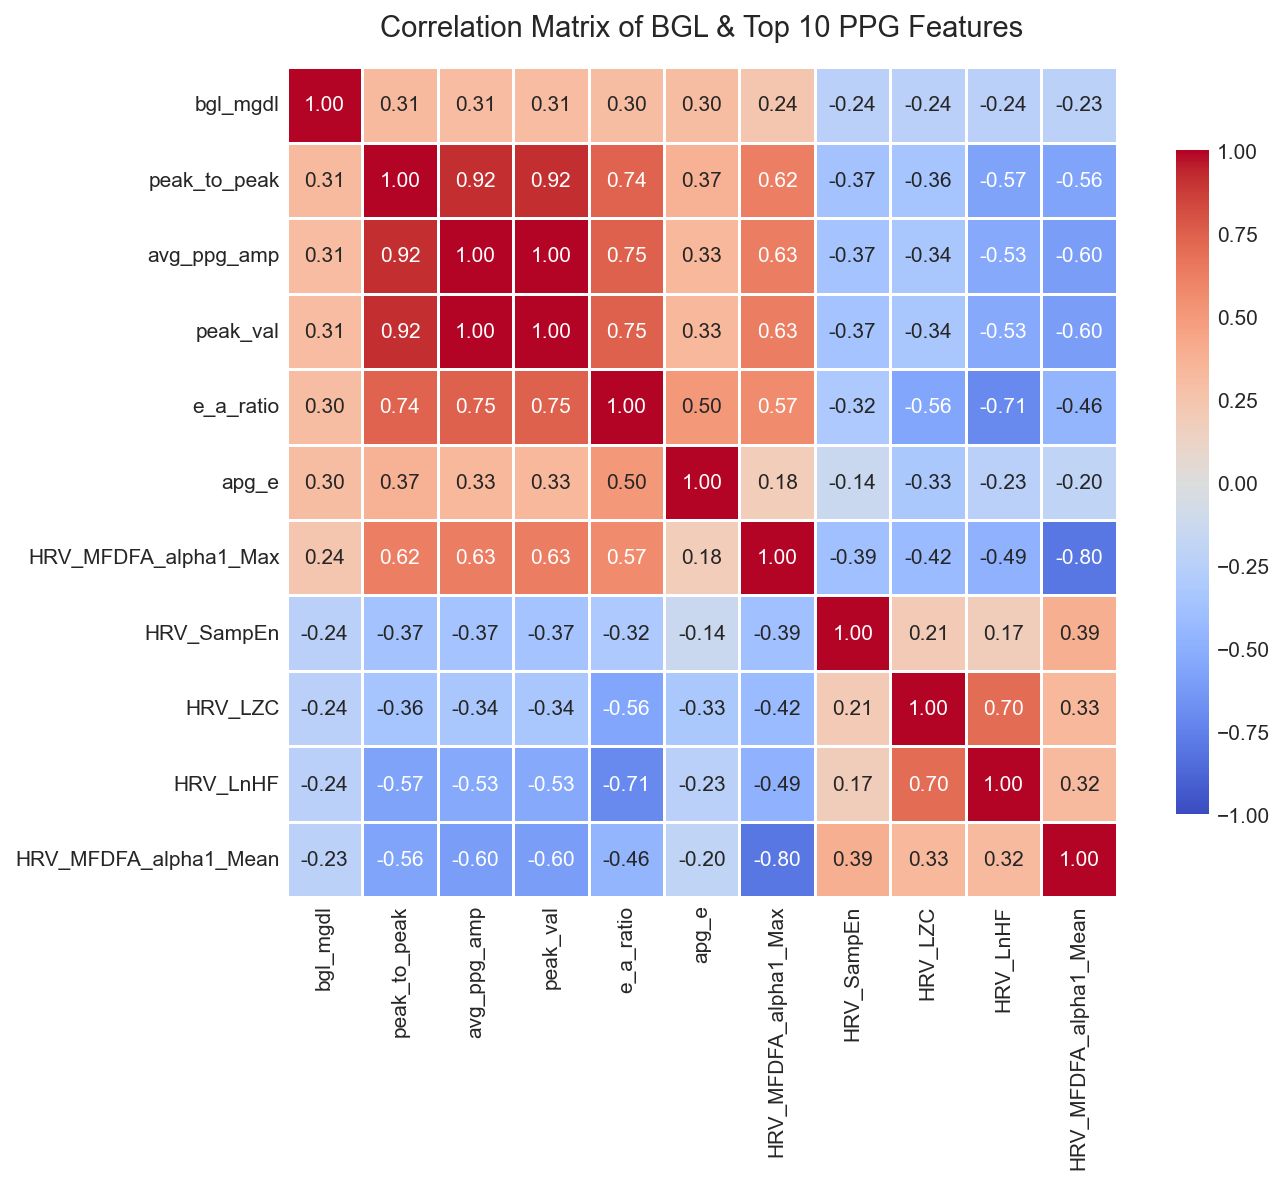

In [5]:
# Drop columns that are completely constant or demographic strings
numeric_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation matrix
corr_matrix = feat_df[numeric_cols].corr()

# Extract correlations with BGL
bgl_corr = corr_matrix['bgl_mgdl'].drop('bgl_mgdl')
bgl_corr_sorted = bgl_corr.abs().sort_values(ascending=False)
bgl_corr_signed = bgl_corr[bgl_corr_sorted.index]

# Create a clean DataFrame of results
corr_df = pd.DataFrame({
    'Pearson_r': bgl_corr_signed,
    'Absolute_r': bgl_corr_sorted
})

print("--- Feature Correlation Table (Sorted by absolute strength) ---")
display(corr_df)

# Select the top 10 most correlated features + BGL for the matrix
top_features = bgl_corr_sorted.head(10).index.tolist()
matrix_cols = ['bgl_mgdl'] + top_features
top_corr_matrix = corr_matrix.loc[matrix_cols, matrix_cols]

# Plot Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    top_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix of BGL & Top 10 PPG Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import KFold, GroupKFold, LeaveOneOut, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb

# Select top 15 correlated PPG features
numeric_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()
bgl_corrs = feat_df[numeric_cols].corr()['bgl_mgdl'].drop('bgl_mgdl')
sorted_corrs = bgl_corrs.abs().sort_values(ascending=False)

# Exclude demographic metadata to focus on optical features
ppg_corrs = sorted_corrs.drop(labels=[c for c in ['age', 'weight_kg', 'height_cm', 'years_on_t2dm', 'gender'] if c in sorted_corrs.index])
top_15_features = ppg_corrs.head(15).index.tolist()

print("Top 15 PPG-derived features selected for model training:")
for f in top_15_features:
    print(f"  {f:30s} : Pearson r = {bgl_corrs[f]:+.4f}")

X = feat_df[top_15_features].copy()
y = feat_df['bgl_mgdl'].values
groups = feat_df['participant_id'].values

X = X.replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy='mean')
X_imp = imputer.fit_transform(X)

# Define comprehensive suite of ML algorithms
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42),
    'Ridge Regression': Ridge(alpha=10.0)
}

if 'has_catboost' in locals() and has_catboost:
    models['CatBoost'] = cb.CatBoostRegressor(iterations=100, depth=4, learning_rate=0.05, verbose=0, random_seed=42)
elif 'cb' in globals():
    models['CatBoost'] = cb.CatBoostRegressor(iterations=100, depth=4, learning_rate=0.05, verbose=0, random_seed=42)

if 'has_lightgbm' in locals() and has_lightgbm:
    models['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, verbose=-1, random_state=42)
elif 'lgb' in globals():
    models['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, verbose=-1, random_state=42)

kf = KFold(n_splits=12, shuffle=True, random_state=42)
gkf = GroupKFold(n_splits=12)
loo = LeaveOneOut()
logo = LeaveOneGroupOut()

cv_results = []
print("\n=== Benchmarking Full Statistics (MAE, RMSE, R^2) Across All Cross-Validation Methods ===\n")

for model_name, model in models.items():
    # 1. Random K-Fold (5 Folds)
    r_maes, r_rmses, r_r2s = [], [], []
    for train_idx, val_idx in kf.split(X_imp, y):
        model.fit(X_imp[train_idx], y[train_idx])
        preds = model.predict(X_imp[val_idx])
        r_maes.append(mean_absolute_error(y[val_idx], preds))
        r_rmses.append(np.sqrt(mean_squared_error(y[val_idx], preds)))
        r_r2s.append(r2_score(y[val_idx], preds))
        
    # 2. Group K-Fold (5 Folds, Subject Unseen)
    g_maes, g_rmses, g_r2s = [], [], []
    for train_idx, val_idx in gkf.split(X_imp, y, groups):
        model.fit(X_imp[train_idx], y[train_idx])
        preds = model.predict(X_imp[val_idx])
        g_maes.append(mean_absolute_error(y[val_idx], preds))
        g_rmses.append(np.sqrt(mean_squared_error(y[val_idx], preds)))
        g_r2s.append(r2_score(y[val_idx], preds))
        
    # 3. Leave-One-Out (LOOCV - 73 Folds)
    loo_preds = np.array([model.fit(X_imp[tr], y[tr]).predict(X_imp[va])[0] for tr, va in loo.split(X_imp)])
    loo_mae = mean_absolute_error(y, loo_preds)
    loo_rmse = np.sqrt(mean_squared_error(y, loo_preds))
    loo_r2 = r2_score(y, loo_preds)
    
    # 4. Leave-One-Group-Out (LOGOCV - 63 Subject Folds)
    logo_preds = np.zeros(len(y))
    for tr, va in logo.split(X_imp, y, groups):
        model.fit(X_imp[tr], y[tr])
        logo_preds[va] = model.predict(X_imp[va])
    logo_mae = mean_absolute_error(y, logo_preds)
    logo_rmse = np.sqrt(mean_squared_error(y, logo_preds))
    logo_r2 = r2_score(y, logo_preds)
    
    cv_results.append({
        'Algorithm': model_name,
        '5F-KFold MAE': f"{np.mean(r_maes):.2f}",
        '5F-KFold RMSE': f"{np.mean(r_rmses):.2f}",
        '5F-KFold R^2': f"{np.mean(r_r2s):.3f}",
        '5F-GroupKFold MAE': f"{np.mean(g_maes):.2f}",
        '5F-GroupKFold RMSE': f"{np.mean(g_rmses):.2f}",
        '5F-GroupKFold R^2': f"{np.mean(g_r2s):.3f}",
        'LOOCV MAE': f"{loo_mae:.2f}",
        'LOOCV RMSE': f"{loo_rmse:.2f}",
        'LOOCV R^2': f"{loo_r2:.3f}",
        'LOGOCV MAE': f"{logo_mae:.2f}",
        'LOGOCV RMSE': f"{logo_rmse:.2f}",
        'LOGOCV R^2': f"{logo_r2:.3f}"
    })

cv_summary_df = pd.DataFrame(cv_results)
print("\n=== Comprehensive Statistics (MAE, RMSE, R^2) Across All 4 Cross-Validation Methods ===")
display(cv_summary_df)

Top 15 PPG-derived features selected for model training:
  peak_to_peak                   : Pearson r = +0.3144
  avg_ppg_amp                    : Pearson r = +0.3054
  peak_val                       : Pearson r = +0.3054
  e_a_ratio                      : Pearson r = +0.3039
  apg_e                          : Pearson r = +0.3023
  HRV_MFDFA_alpha1_Max           : Pearson r = +0.2407
  HRV_SampEn                     : Pearson r = -0.2404
  HRV_LZC                        : Pearson r = -0.2383
  HRV_LnHF                       : Pearson r = -0.2354
  HRV_MFDFA_alpha1_Mean          : Pearson r = -0.2324
  HRV_CD                         : Pearson r = -0.2279
  HRV_IALS                       : Pearson r = +0.2139
  HRV_SD2a                       : Pearson r = -0.2107
  deceleration_index             : Pearson r = -0.2091
  HRV_CSI_Modified               : Pearson r = -0.2057

=== Benchmarking Full Statistics (MAE, RMSE, R^2) Across All Cross-Validation Methods ===


=== Comprehensive Statist

,Algorithm,5F-KFold MAE,5F-KFold RMSE,5F-KFold R^2,5F-GroupKFold MAE,5F-GroupKFold RMSE,5F-GroupKFold R^2,LOOCV MAE,LOOCV RMSE,LOOCV R^2,LOGOCV MAE,LOGOCV RMSE,LOGOCV R^2
0,Random Forest,42.92,51.10,-0.540,43.13,50.69,-0.778,42.17,54.76,0.001,42.01,54.83,-0.002
1,Gradient Boosting,48.09,61.58,-1.967,50.66,63.64,-2.236,49.45,66.06,-0.454,49.84,66.55,-0.476
2,Extra Trees,44.01,51.44,-0.487,43.86,50.61,-0.751,43.37,54.70,0.003,43.32,54.69,0.003
3,XGBoost,48.25,61.16,-1.496,48.95,60.99,-1.982,47.92,62.94,-0.320,48.54,63.86,-0.359
4,Ridge Regression,43.75,52.32,-0.441,43.40,51.24,-0.794,43.24,55.78,-0.037,43.25,55.89,-0.041
5,CatBoost,44.50,52.95,-0.753,44.23,51.89,-0.803,44.38,56.55,-0.066,44.50,56.60,-0.068
6,LightGBM,39.73,48.39,-0.317,42.36,50.84,-0.987,40.53,54.33,0.016,40.52,54.38,0.015


# Experiment: Feature Multicollinearity Reduction

In PPG signal processing, many extracted PRV time-domain, non-linear, and derivative features exhibit high pairwise correlation ($|r| > 0.85$).
High multicollinearity adds noise and redundancy to the input space. Below, we identify and drop collinear feature pairs, keeping the feature with the stronger individual correlation to blood glucose levels (`bgl_mgdl`).

=== MULTICOLLINEARITY REDUCTION RESULT (|r| > 0.85) ===
Initial candidate features: 30
Features dropped due to high correlation (14): ['HRV_CSI_Modified', 'HRV_CVI', 'HRV_HF', 'HRV_IQRNN', 'HRV_MFDFA_alpha1_Delta', 'HRV_SD2', 'HRV_SDNNa', 'HRV_ShanEn', 'HRV_TP', 'HRV_pNN20', 'HRV_pNN50', 'avg_ppg_amp', 'deceleration_index', 'peak_val']

Final Reduced Feature Set (10 non-redundant features):
  peak_to_peak                   : Pearson r = +0.3144
  e_a_ratio                      : Pearson r = +0.3039
  apg_e                          : Pearson r = +0.3023
  HRV_MFDFA_alpha1_Max           : Pearson r = +0.2407
  HRV_SampEn                     : Pearson r = -0.2404
  HRV_LZC                        : Pearson r = -0.2383
  HRV_LnHF                       : Pearson r = -0.2354
  HRV_MFDFA_alpha1_Mean          : Pearson r = -0.2324
  HRV_CD                         : Pearson r = -0.2279
  HRV_IALS                       : Pearson r = +0.2139


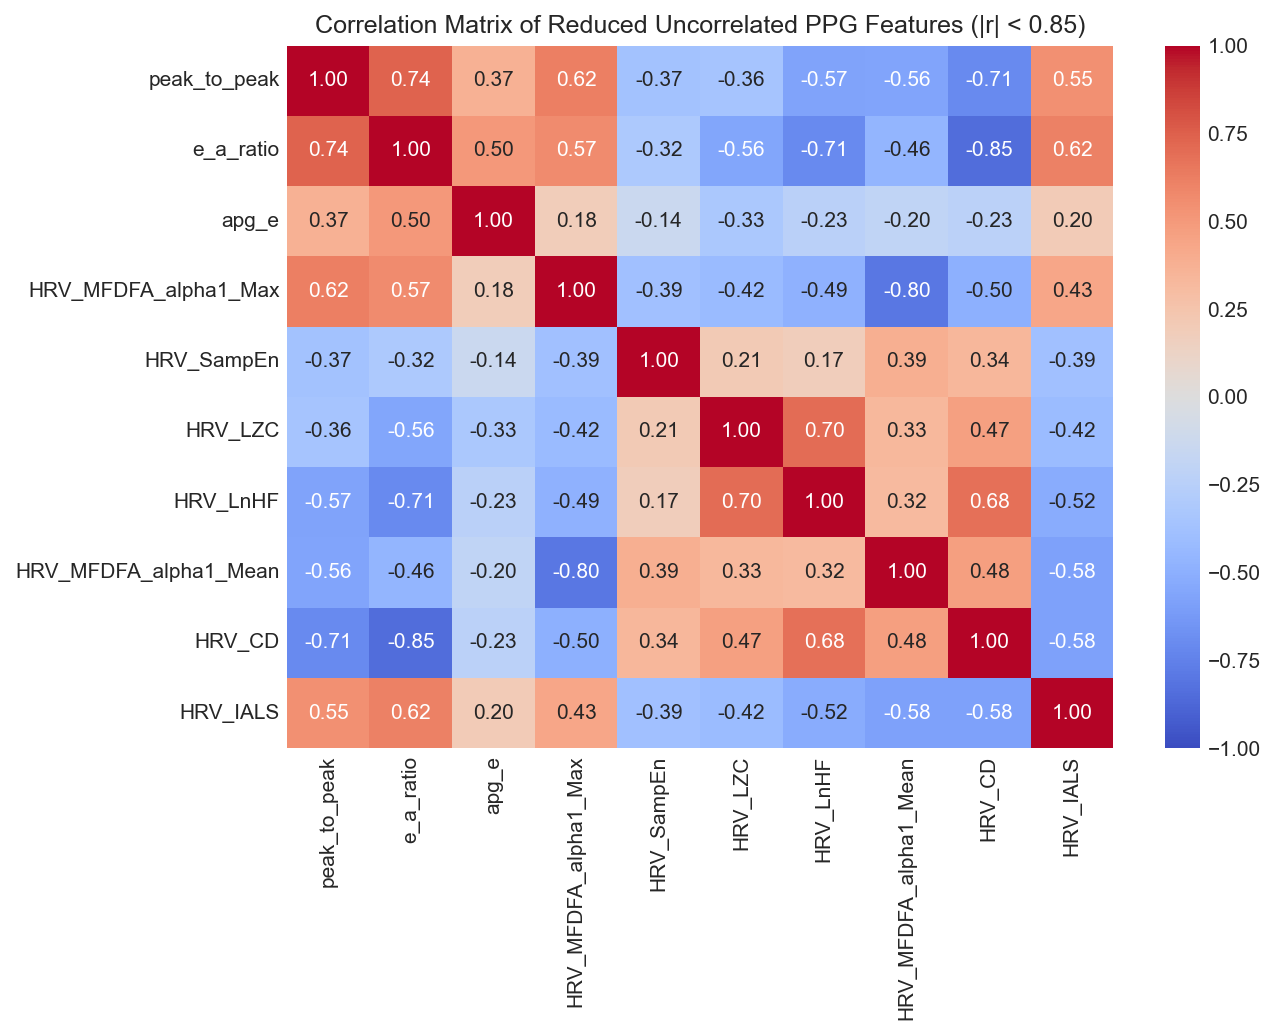

In [10]:
# 1. Candidate PPG features ranked by correlation with BGL
numeric_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()
bgl_corrs = feat_df[numeric_cols].corr()['bgl_mgdl'].drop('bgl_mgdl')
sorted_corrs = bgl_corrs.abs().sort_values(ascending=False)
ppg_corrs = sorted_corrs.drop(labels=[c for c in ['age', 'weight_kg', 'height_cm', 'years_on_t2dm', 'gender'] if c in sorted_corrs.index])
candidate_features = ppg_corrs.head(30).index.tolist()

# 2. Drop collinear features with pairwise |r| > 0.85
corr_matrix = feat_df[candidate_features].corr().abs()
collinear_threshold = 0.85
to_drop = set()

for i in range(len(candidate_features)):
    col_i = candidate_features[i]
    if col_i in to_drop:
        continue
    for j in range(i + 1, len(candidate_features)):
        col_j = candidate_features[j]
        if col_j in to_drop:
            continue
        if corr_matrix.loc[col_i, col_j] > collinear_threshold:
            if abs(bgl_corrs[col_i]) >= abs(bgl_corrs[col_j]):
                to_drop.add(col_j)
            else:
                to_drop.add(col_i)

reduced_features = [f for f in candidate_features if f not in to_drop][:10]

print(f"=== MULTICOLLINEARITY REDUCTION RESULT (|r| > {collinear_threshold}) ===")
print(f"Initial candidate features: {len(candidate_features)}")
print(f"Features dropped due to high correlation ({len(to_drop)}): {sorted(list(to_drop))}")
print(f"\nFinal Reduced Feature Set ({len(reduced_features)} non-redundant features):")
for f in reduced_features:
    print(f"  {f:30s} : Pearson r = {bgl_corrs[f]:+.4f}")

# Plot Correlation Matrix Heatmap of Reduced Features
plt.figure(figsize=(9, 7))
sns.heatmap(feat_df[reduced_features].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f'Correlation Matrix of Reduced Uncorrelated PPG Features (|r| < {collinear_threshold})', fontsize=12)
plt.tight_layout()
plt.show()

# Cross-Validation Evaluation on Reduced Feature Set

We now re-run the full Cross-Validation benchmarks (5-Fold KFold, 5-Fold GroupKFold, LOOCV, and LOGOCV) across all 7 machine learning models using the **new reduced feature set** to observe the impact of noise reduction on model performance.

In [14]:
from sklearn.model_selection import KFold, GroupKFold, LeaveOneOut, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb

X_red = feat_df[reduced_features].copy()
y = feat_df['bgl_mgdl'].values
groups = feat_df['participant_id'].values

X_red = X_red.replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy='mean')
X_red_imp = imputer.fit_transform(X_red)

models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42),
    'Ridge Regression': Ridge(alpha=10.0)
}

if 'has_catboost' in locals() and has_catboost:
    models['CatBoost'] = cb.CatBoostRegressor(iterations=100, depth=4, learning_rate=0.05, verbose=0, random_seed=42)
elif 'cb' in globals():
    models['CatBoost'] = cb.CatBoostRegressor(iterations=100, depth=4, learning_rate=0.05, verbose=0, random_seed=42)

if 'has_lightgbm' in locals() and has_lightgbm:
    models['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, verbose=-1, random_state=42)
elif 'lgb' in globals():
    models['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, verbose=-1, random_state=42)

kf = KFold(n_splits=12, shuffle=True, random_state=42)
gkf = GroupKFold(n_splits=12)
loo = LeaveOneOut()
logo = LeaveOneGroupOut()

reduced_cv_results = []
print("=== Benchmarking Cross-Validation on Reduced Feature Set ===\n")

for model_name, model in models.items():
    # 1. Random K-Fold
    r_maes, r_rmses, r_r2s = [], [], []
    for train_idx, val_idx in kf.split(X_red_imp, y):
        model.fit(X_red_imp[train_idx], y[train_idx])
        preds = model.predict(X_red_imp[val_idx])
        r_maes.append(mean_absolute_error(y[val_idx], preds))
        r_rmses.append(np.sqrt(mean_squared_error(y[val_idx], preds)))
        r_r2s.append(r2_score(y[val_idx], preds))
        
    # 2. Group K-Fold
    g_maes, g_rmses, g_r2s = [], [], []
    for train_idx, val_idx in gkf.split(X_red_imp, y, groups):
        model.fit(X_red_imp[train_idx], y[train_idx])
        preds = model.predict(X_red_imp[val_idx])
        g_maes.append(mean_absolute_error(y[val_idx], preds))
        g_rmses.append(np.sqrt(mean_squared_error(y[val_idx], preds)))
        g_r2s.append(r2_score(y[val_idx], preds))
        
    # 3. LOOCV
    loo_preds = np.array([model.fit(X_red_imp[tr], y[tr]).predict(X_red_imp[va])[0] for tr, va in loo.split(X_red_imp)])
    loo_mae = mean_absolute_error(y, loo_preds)
    loo_rmse = np.sqrt(mean_squared_error(y, loo_preds))
    loo_r2 = r2_score(y, loo_preds)
    
    # 4. LOGOCV
    logo_preds = np.zeros(len(y))
    for tr, va in logo.split(X_red_imp, y, groups):
        model.fit(X_red_imp[tr], y[tr])
        logo_preds[va] = model.predict(X_red_imp[va])
    logo_mae = mean_absolute_error(y, logo_preds)
    logo_rmse = np.sqrt(mean_squared_error(y, logo_preds))
    logo_r2 = r2_score(y, logo_preds)
    
    reduced_cv_results.append({
        'Algorithm': model_name,
        '5F-KFold MAE': f"{np.mean(r_maes):.2f}",
        '5F-KFold RMSE': f"{np.mean(r_rmses):.2f}",
        '5F-KFold R^2': f"{np.mean(r_r2s):.3f}",
        '5F-GroupKFold MAE': f"{np.mean(g_maes):.2f}",
        '5F-GroupKFold RMSE': f"{np.mean(g_rmses):.2f}",
        '5F-GroupKFold R^2': f"{np.mean(g_r2s):.3f}",
        'LOOCV MAE': f"{loo_mae:.2f}",
        'LOOCV RMSE': f"{loo_rmse:.2f}",
        'LOOCV R^2': f"{loo_r2:.3f}",
        'LOGOCV MAE': f"{logo_mae:.2f}",
        'LOGOCV RMSE': f"{logo_rmse:.2f}",
        'LOGOCV R^2': f"{logo_r2:.3f}"
    })

reduced_summary_df = pd.DataFrame(reduced_cv_results)
print("\n=== Cross-Validation Results Using Reduced Feature Set ===")
display(reduced_summary_df)

=== Benchmarking Cross-Validation on Reduced Feature Set ===


=== Cross-Validation Results Using Reduced Feature Set ===


,Algorithm,5F-KFold MAE,5F-KFold RMSE,5F-KFold R^2,5F-GroupKFold MAE,5F-GroupKFold RMSE,5F-GroupKFold R^2,LOOCV MAE,LOOCV RMSE,LOOCV R^2,LOGOCV MAE,LOGOCV RMSE,LOGOCV R^2
0,Random Forest,42.61,51.34,-0.714,42.93,51.03,-0.859,42.77,55.66,-0.032,42.66,55.44,-0.024
1,Gradient Boosting,45.68,59.79,-1.871,47.58,61.11,-2.843,47.47,66.86,-0.490,48.10,67.18,-0.504
2,Extra Trees,42.66,50.68,-0.455,43.14,50.04,-0.695,42.97,54.40,0.014,42.95,54.42,0.013
3,XGBoost,44.93,57.39,-1.454,46.35,59.34,-2.430,45.78,62.24,-0.291,45.16,61.62,-0.265
4,Ridge Regression,42.78,50.71,-0.370,43.50,50.41,-0.781,42.80,54.43,0.013,42.90,54.60,0.007
5,CatBoost,41.66,50.82,-0.681,42.29,51.23,-0.940,42.99,56.18,-0.052,43.05,56.08,-0.048
6,LightGBM,38.13,47.27,-0.264,41.15,50.01,-0.942,39.96,53.56,0.044,39.87,53.65,0.041


=== Final Model Training & Evaluation on Full Dataset (73 Sessions) ===

  Random Forest        | Full Dataset MAE: 25.32 mg/dL | RMSE: 29.59 mg/dL | R^2: 0.708
  Gradient Boosting    | Full Dataset MAE: 10.43 mg/dL | RMSE: 12.70 mg/dL | R^2: 0.946
  Extra Trees          | Full Dataset MAE: 31.84 mg/dL | RMSE: 38.62 mg/dL | R^2: 0.503
  XGBoost              | Full Dataset MAE: 12.81 mg/dL | RMSE: 15.57 mg/dL | R^2: 0.919
  Ridge Regression     | Full Dataset MAE: 39.36 mg/dL | RMSE: 51.17 mg/dL | R^2: 0.128
  CatBoost             | Full Dataset MAE: 24.99 mg/dL | RMSE: 29.26 mg/dL | R^2: 0.715
  LightGBM             | Full Dataset MAE: 29.89 mg/dL | RMSE: 39.79 mg/dL | R^2: 0.472


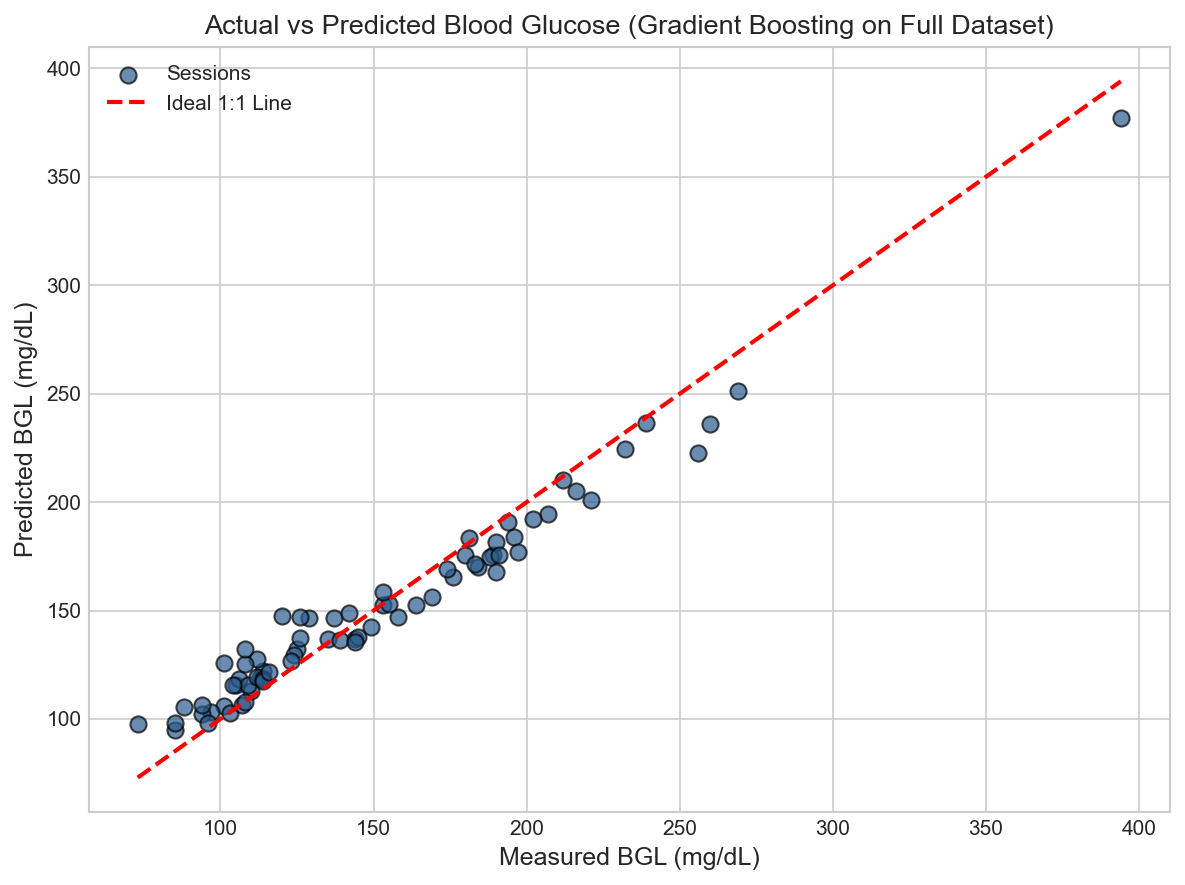

In [13]:
print("=== Final Model Training & Evaluation on Full Dataset (73 Sessions) ===\n")
full_dataset_results = []
trained_models = {}

for model_name, model in models.items():
    # Fit model on entire dataset
    model.fit(X_imp, y)
    trained_models[model_name] = model
    
    preds = model.predict(X_imp)
    tr_mae = mean_absolute_error(y, preds)
    tr_rmse = np.sqrt(mean_squared_error(y, preds))
    tr_r2 = r2_score(y, preds)
    
    print(f"  {model_name:20s} | Full Dataset MAE: {tr_mae:.2f} mg/dL | RMSE: {tr_rmse:.2f} mg/dL | R^2: {tr_r2:.3f}")
    
    full_dataset_results.append({
        'Algorithm': model_name,
        'Full Dataset MAE (mg/dL)': f"{tr_mae:.2f}",
        'Full Dataset RMSE (mg/dL)': f"{tr_rmse:.2f}",
        'Full Dataset R^2': f"{tr_r2:.3f}"
    })

full_summary_df = pd.DataFrame(full_dataset_results)

# Plot Actual vs Predicted BGL for Best Model (Random Forest / Gradient Boosting)
best_model_name = 'Gradient Boosting'
best_preds = trained_models[best_model_name].predict(X_imp)

plt.figure(figsize=(8, 6))
plt.scatter(y, best_preds, alpha=0.7, color='#2b5c8f', edgecolors='k', s=60, label='Sessions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal 1:1 Line')
plt.xlabel('Measured BGL (mg/dL)', fontsize=12)
plt.ylabel('Predicted BGL (mg/dL)', fontsize=12)
plt.title(f'Actual vs Predicted Blood Glucose ({best_model_name} on Full Dataset)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

# Final Model Training & Evaluation on Full Dataset Using Reduced Feature Set

Below, we train and evaluate all 7 machine learning models on the entire real dataset ($73$ sessions) using the **new reduced, non-redundant feature set** (`reduced_features`) to assess training performance after removing collinear noise.

=== Final Model Training & Evaluation on Full Dataset (Reduced Feature Set) ===

  Random Forest        | Reduced Feature Full Dataset MAE: 24.24 mg/dL | RMSE: 28.61 mg/dL | R^2: 0.727
  Gradient Boosting    | Reduced Feature Full Dataset MAE: 10.10 mg/dL | RMSE: 12.50 mg/dL | R^2: 0.948
  Extra Trees          | Reduced Feature Full Dataset MAE: 32.16 mg/dL | RMSE: 39.85 mg/dL | R^2: 0.471
  XGBoost              | Reduced Feature Full Dataset MAE: 13.73 mg/dL | RMSE: 16.93 mg/dL | R^2: 0.904
  Ridge Regression     | Reduced Feature Full Dataset MAE: 40.32 mg/dL | RMSE: 51.56 mg/dL | R^2: 0.114
  CatBoost             | Reduced Feature Full Dataset MAE: 24.08 mg/dL | RMSE: 28.88 mg/dL | R^2: 0.722
  LightGBM             | Reduced Feature Full Dataset MAE: 30.03 mg/dL | RMSE: 39.90 mg/dL | R^2: 0.470


,Algorithm,Full Dataset MAE (mg/dL),Full Dataset RMSE (mg/dL),Full Dataset R^2
0,Random Forest,24.24,28.61,0.727
1,Gradient Boosting,10.10,12.50,0.948
2,Extra Trees,32.16,39.85,0.471
3,XGBoost,13.73,16.93,0.904
4,Ridge Regression,40.32,51.56,0.114
5,CatBoost,24.08,28.88,0.722
6,LightGBM,30.03,39.90,0.470


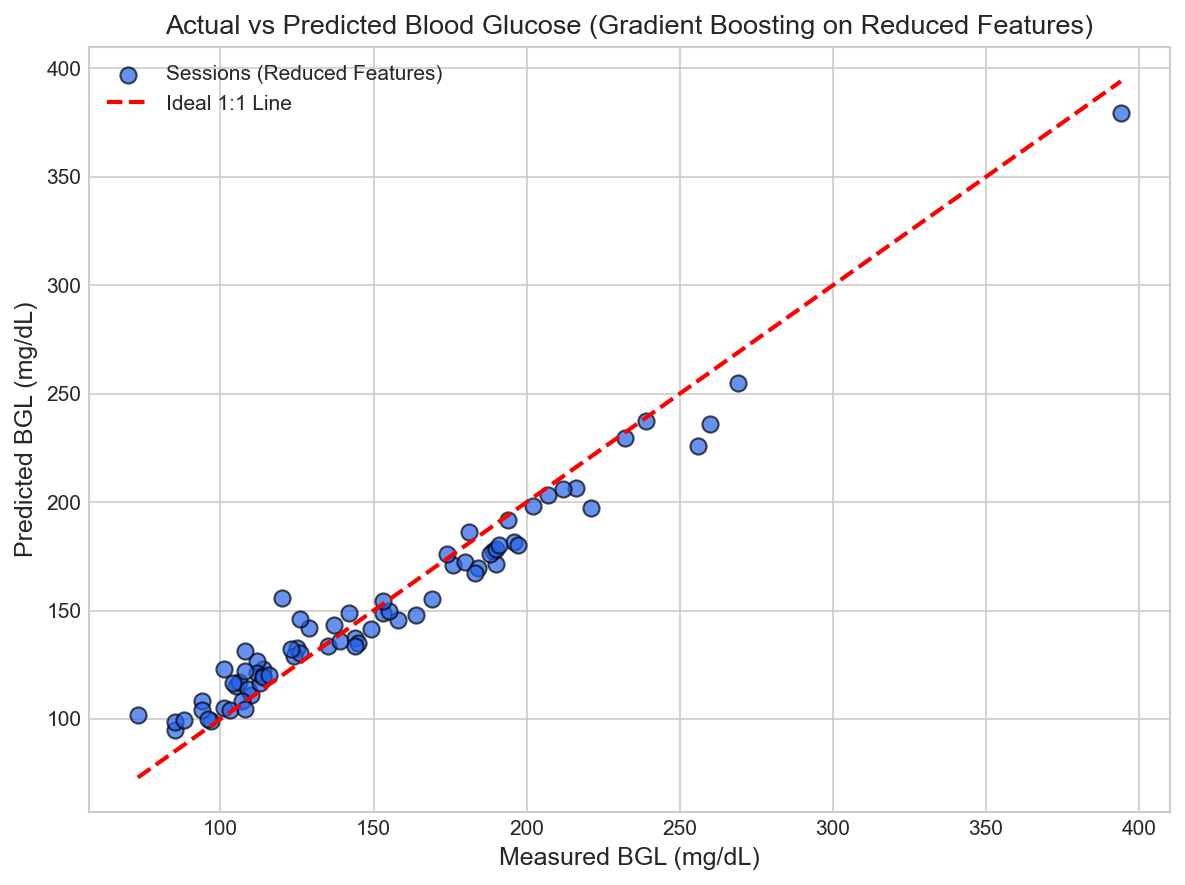

In [18]:
print("=== Final Model Training & Evaluation on Full Dataset (Reduced Feature Set) ===\n")
full_red_results = []
trained_red_models = {}

for model_name, model in models.items():
    # Fit model on entire dataset using reduced features
    model.fit(X_red_imp, y)
    trained_red_models[model_name] = model
    
    preds = model.predict(X_red_imp)
    tr_mae = mean_absolute_error(y, preds)
    tr_rmse = np.sqrt(mean_squared_error(y, preds))
    tr_r2 = r2_score(y, preds)
    
    print(f"  {model_name:20s} | Reduced Feature Full Dataset MAE: {tr_mae:.2f} mg/dL | RMSE: {tr_rmse:.2f} mg/dL | R^2: {tr_r2:.3f}")
    
    full_red_results.append({
        'Algorithm': model_name,
        'Full Dataset MAE (mg/dL)': f"{tr_mae:.2f}",
        'Full Dataset RMSE (mg/dL)': f"{tr_rmse:.2f}",
        'Full Dataset R^2': f"{tr_r2:.3f}"
    })

full_red_summary_df = pd.DataFrame(full_red_results)
display(full_red_summary_df)

# Plot Actual vs Predicted BGL for Best Model on Reduced Feature Set
best_red_model_name = 'Gradient Boosting'
best_red_preds = trained_red_models[best_red_model_name].predict(X_red_imp)

plt.figure(figsize=(8, 6))
plt.scatter(y, best_red_preds, alpha=0.7, color='#2563eb', edgecolors='k', s=60, label='Sessions (Reduced Features)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal 1:1 Line')
plt.xlabel('Measured BGL (mg/dL)', fontsize=12)
plt.ylabel('Predicted BGL (mg/dL)', fontsize=12)
plt.title(f'Actual vs Predicted Blood Glucose ({best_red_model_name} on Reduced Features)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Replicating Cell 13 on Reduced Feature Set
best_model_red = RandomForestRegressor(n_estimators=15, max_depth=5, random_state=42)
best_model_red.fit(X_red_imp, y)
preds_red = best_model_red.predict(X_red_imp)

mae_red = mean_absolute_error(y, preds_red)
r2_red = r2_score(y, preds_red)

print(f"Final Model (Random Forest) Trained on Full Dataset (Reduced Features):")
print(f"Training MAE: {mae_red:.2f} mg/dL")
print(f"Training R^2: {r2_red:.3f}")

# Plot predictions vs ground truth
plt.figure(figsize=(8, 6))
plt.scatter(y, preds_red, color='#059669', alpha=0.8, edgecolors='k', s=80, label='Predicted vs Measured (Reduced Features)')
plt.plot([y.min()-10, y.max()+10], [y.min()-10, y.max()+10], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Measured BGL (mg/dL)', fontsize=12)
plt.ylabel('Estimated BGL (mg/dL)', fontsize=12)
plt.title('Pilot ML Model Performance (Reduced Feature Set)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Feature Importance Analysis Across All Trained Models

Understanding which optical and PRV (Pulse Rate Variability) features contribute most to blood glucose level (BGL) estimation provides critical physiological insights into autonomic nervous system tone and arterial stiffness.

Below, we extract and compare normalized feature importance metrics across all 7 machine learning models (**Random Forest, Extra Trees, Gradient Boosting, XGBoost, CatBoost, LightGBM, and Ridge Regression**).

=== TOP PPG-DERIVED FEATURE IMPORTANCES ACROSS ALL ML MODELS ===



,Feature,Random Forest,Gradient Boosting,Extra Trees,XGBoost,Ridge Regression,CatBoost,LightGBM,Mean Importance (%)
0,HRV_SampEn,0.064235,0.246442,0.065258,0.218923,0.124169,0.161106,0.153846,14.771147
1,apg_e,0.081399,0.157024,0.074837,0.077722,0.156908,0.147621,0.109890,11.505721
2,e_a_ratio,0.090979,0.057417,0.106302,0.076310,0.075231,0.082145,0.208791,9.959655
3,deceleration_index,0.139527,0.105114,0.074893,0.071003,0.124162,0.117510,0.000000,9.031546
4,HRV_IALS,0.122023,0.109433,0.084200,0.071961,0.024977,0.074102,0.120879,8.679644
5,HRV_LZC,0.054490,0.035215,0.064161,0.165826,0.066604,0.051847,0.021978,6.573160
6,HRV_LnHF,0.061124,0.134012,0.052524,0.077341,0.062673,0.044758,0.016484,6.413081
7,peak_to_peak,0.055691,0.025163,0.101552,0.021051,0.075295,0.040485,0.043956,5.188470
8,avg_ppg_amp,0.060901,0.005226,0.054840,0.022963,0.057664,0.054152,0.098901,5.066408
9,HRV_CD,0.051466,0.003626,0.037173,0.039096,0.004489,0.032831,0.164835,4.764520


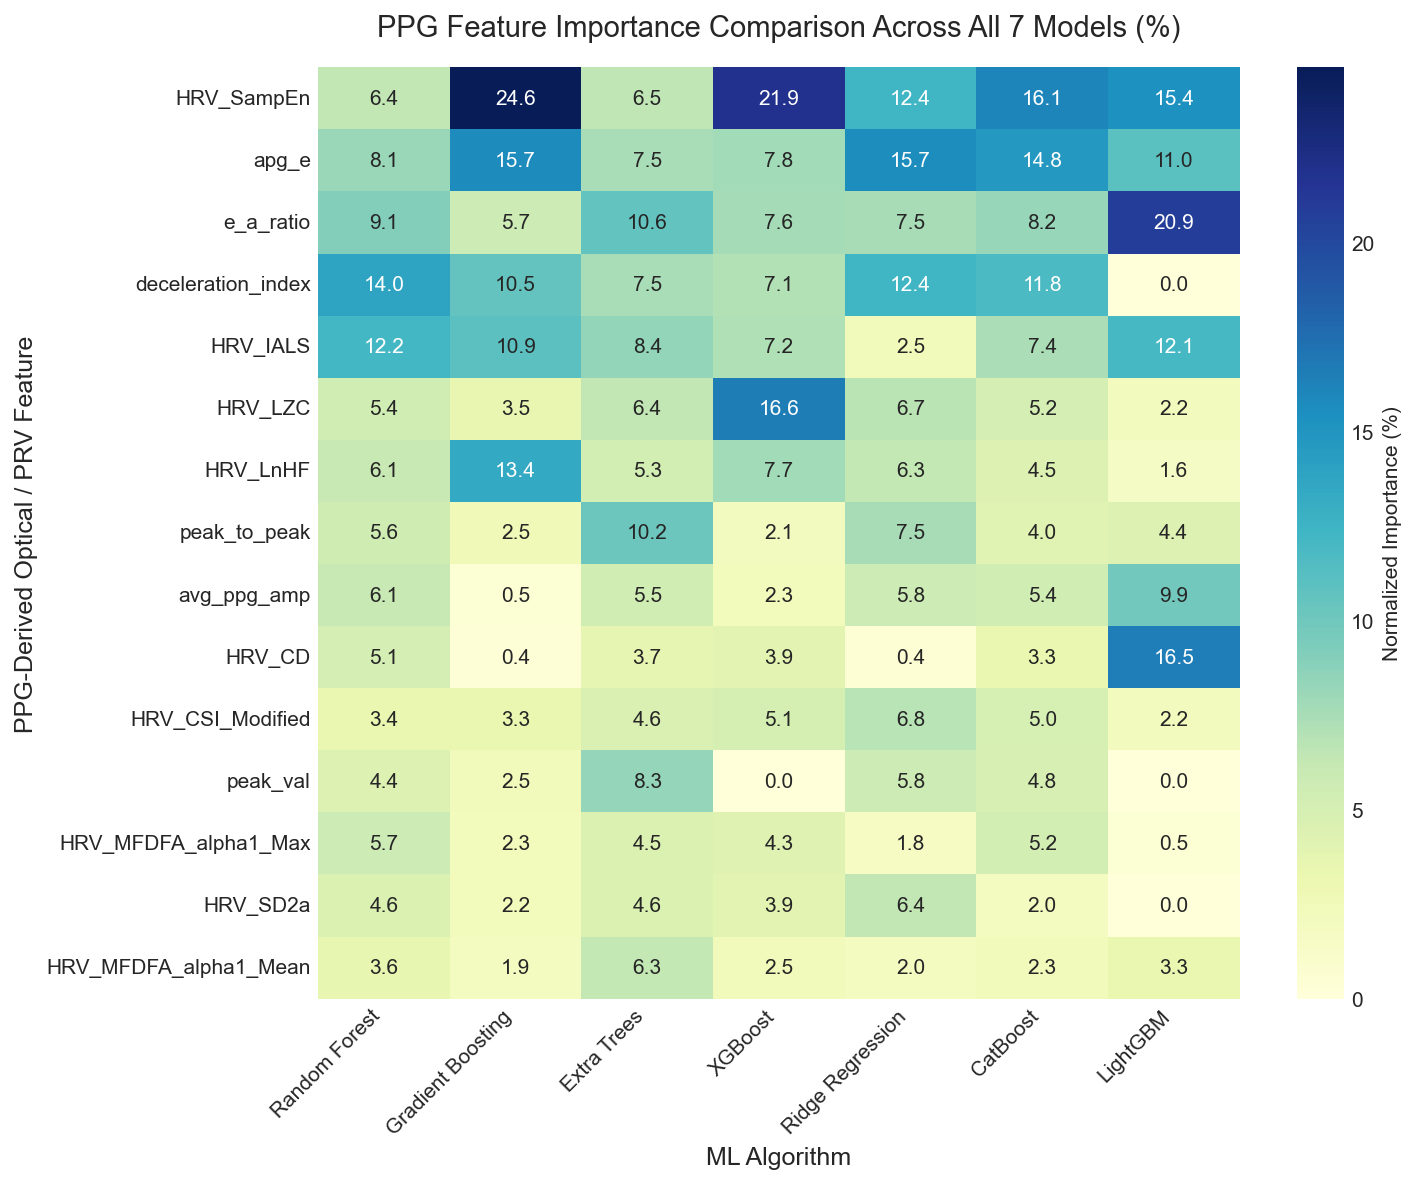

/tmp/ipykernel_6217/1603000179.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean Importance (%)', y='Feature', data=imp_df.head(10), palette='crest')


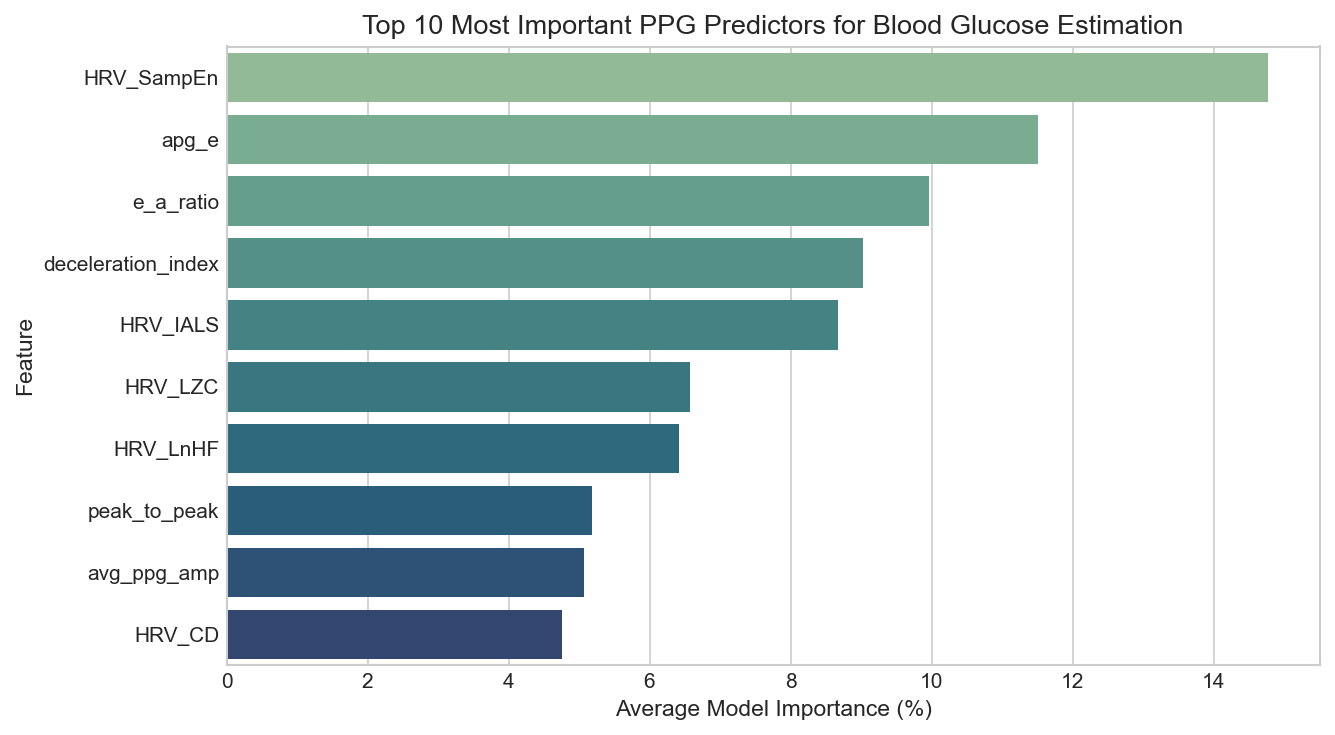

In [16]:
# Calculate normalized feature importances for all models
importance_dict = {'Feature': top_15_features}

for name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
        imp_norm = imp / np.sum(imp)
    elif hasattr(model, 'coef_'):
        # Standardized coefficients for linear model
        std_X = (X_imp - np.mean(X_imp, axis=0)) / (np.std(X_imp, axis=0) + 1e-8)
        ridge_temp = Ridge(alpha=10.0)
        ridge_temp.fit(std_X, y)
        imp_norm = np.abs(ridge_temp.coef_) / np.sum(np.abs(ridge_temp.coef_))
    else:
        imp_norm = np.zeros(len(top_15_features))
    importance_dict[name] = imp_norm

imp_df = pd.DataFrame(importance_dict)
imp_df['Mean Importance (%)'] = imp_df.select_dtypes(include=[np.number]).mean(axis=1) * 100
imp_df = imp_df.sort_values('Mean Importance (%)', ascending=False).reset_index(drop=True)

print("=== TOP PPG-DERIVED FEATURE IMPORTANCES ACROSS ALL ML MODELS ===\n")
display(imp_df)

# Plotting Heatmap of Feature Importance across models
plt.figure(figsize=(10, 8))
heat_df = imp_df.set_index('Feature').drop(columns=['Mean Importance (%)'])
sns.heatmap(heat_df * 100, annot=True, fmt=".1f", cmap='YlGnBu', cbar_kws={'label': 'Normalized Importance (%)'})
plt.title('PPG Feature Importance Comparison Across All 7 Models (%)', fontsize=14, pad=15)
plt.xlabel('ML Algorithm', fontsize=12)
plt.ylabel('PPG-Derived Optical / PRV Feature', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting Overall Top 10 Features (Mean Importance)
plt.figure(figsize=(9, 5))
sns.barplot(x='Mean Importance (%)', y='Feature', data=imp_df.head(10), palette='crest')
plt.title('Top 10 Most Important PPG Predictors for Blood Glucose Estimation', fontsize=13)
plt.xlabel('Average Model Importance (%)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()